<a href="https://colab.research.google.com/github/Alancin321/Examen-1-bimestral-ISI/blob/main/Examen_1_Bimestral_ISI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Reporte Analítico: Gestión de Talento Humano (HRIS)

---

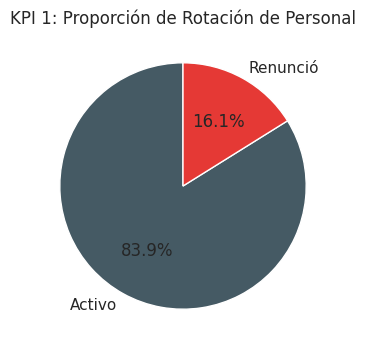

**Resultado:** Se fue el **16.12%** de los empleados.

**Interpretación** Básicamente, se está yendo demasiada gente. Si perdemos a más del 16% de la plantilla, la empresa va a empezar a gastar muchísimo dinero buscando y entrenando reemplazos, además de perder a empleados que ya sabían hacer bien su trabajo.

/tmp/ipykernel_3842/1048356412.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Departamento', y='MonthlyIncome', palette='Blues_r', errorbar=None)


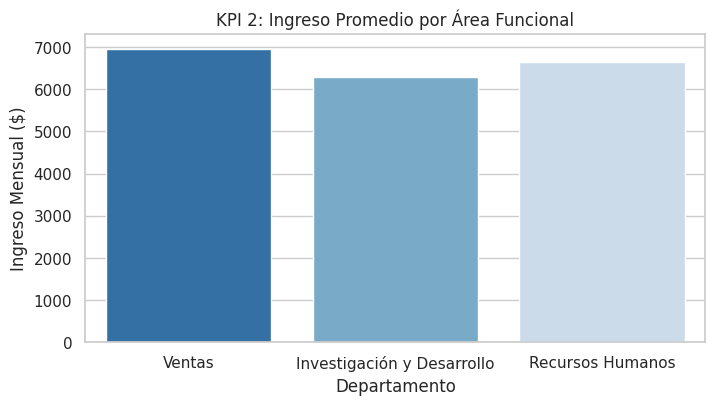

**Resultado:** En Ventas ganan en promedio **6959.17** y en Investigación **6281.25** , pero en Recursos Humanos solo **6654.51** , todo esto en dolares.

**Interpretación** Hay una diferencia de sueldos injusta. Los de Recursos Humanos están ganando bastante menos que las otras áreas. Si no les mejoramos el sueldo para igualarlos, lo más seguro es que terminen renunciando para irse a la competencia.

/tmp/ipykernel_3842/1048356412.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='WorkLifeBalance', y='Cargo_Espanol', palette='flare', errorbar=None)


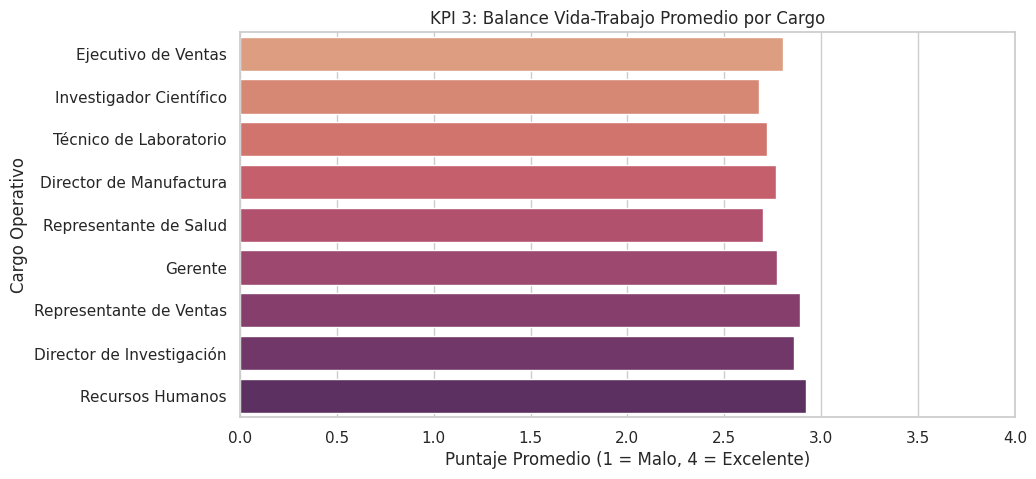

**Resultado:** La empresa en general tiene un balance aceptable, pero el cargo de **Investigador Científico** tiene la peor calificación con **2.68 sobre 4.00**.

**Interpretación** Los empleados de este cargo están trabajando demasiado y no tienen vida personal. Si los jefes no les quitan un poco de carga de trabajo pronto, esta gente se va a agotar por el estrés y terminará renunciando.

/tmp/ipykernel_3842/1048356412.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Brecha_Estancamiento', y='Cargo_Espanol', palette='crest', errorbar=None)


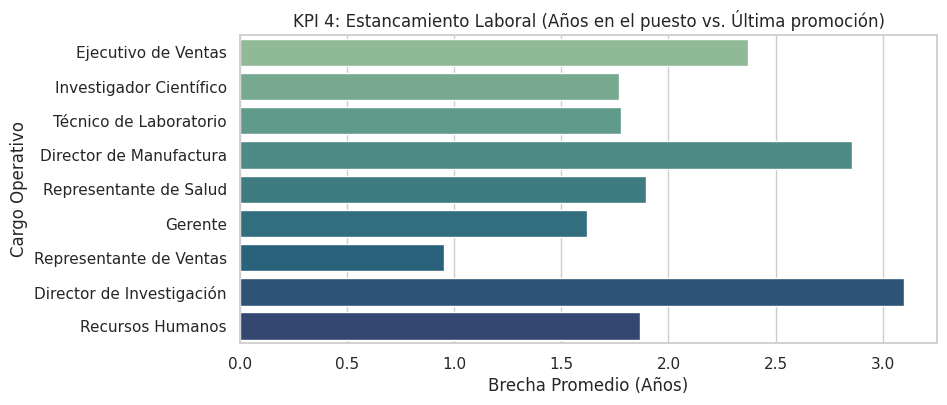

**Resultado:** En promedio, la gente lleva **2.04 años** sin que la asciendan. El peor caso es el de **Director de Investigación**, que lleva **3.10 años** atascado en el mismo puesto.

**Interpretación** Tenemos a personas que llevan muchísimo tiempo haciendo lo mismo sin recibir una promoción. Esto es peligroso porque el empleado se aburre, se desmotiva, deja de esforzarse y siente que no tiene futuro en la empresa.


---
### Resumen Rápido de Problemas

| ¿Qué medimos? | ¿Qué encontramos? |
| :--- | :--- |
| **Gente que se va** | Perdimos al **16.12%** del personal. Es un número muy alto. |
| **Sueldos** | Los de Recursos Humanos ganan mucho menos dinero que el resto. |
| **Estrés** | El puesto de **Investigador Científico** es el más explotado y sin tiempo libre. |
| **Estancamiento** | El puesto de **Director de Investigación** lleva **3.10 años** sin recibir un ascenso. |


In [25]:

# Librerias necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Le pongo un fondo blanco con cuadrícula a todos mis gráficos
sns.set_theme(style="whitegrid")

# Leo el archivo CSV
df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv', encoding='latin1')


# 2. Traduccion

#Limpiamos los datos
#Creamos nuevas columnas con su transformación adecuada y creo diccionarios
df['Estado'] = df['Attrition'].map({'Yes': 'Renunció', 'No': 'Activo'})

# Armamos un diccionario para traducir los 3 departamentos necesarios
diccionario_dept = {'Sales': 'Ventas','Research & Development': 'Investigación y Desarrollo','Human Resources': 'Recursos Humanos'}
# creo una nueva columna traducida.
df['Departamento'] = df['Department'].map(diccionario_dept)

# Diccionario para traducir todos los puestos de trabajo
diccionario_cargos = {
    'Sales Executive': 'Ejecutivo de Ventas',
    'Research Scientist': 'Investigador Científico',
    'Laboratory Technician': 'Técnico de Laboratorio',
    'Manufacturing Director': 'Director de Manufactura',
    'Healthcare Representative': 'Representante de Salud',
    'Manager': 'Gerente',
    'Sales Representative': 'Representante de Ventas',
    'Research Director': 'Director de Investigación',
    'Human Resources': 'Recursos Humanos'
}
# Guardamos los cargos en español en una columna nueva.
df['Cargo_Espanol'] = df['JobRole'].map(diccionario_cargos)

# Para el KPI 4: Diseño mi métrica de estancamiento laboral.
# Le resto a los años en el puesto actual los años desde el último ascenso.
df['Brecha_Estancamiento'] = df['YearsInCurrentRole'] - df['YearsSinceLastPromotion']


# 3. Creación de los KPI's

# Imprimo el encabezado principal de mi reporte.
display(Markdown("### Reporte Analítico: Gestión de Talento Humano (HRIS)"))
display(Markdown("---"))


# KPI 1: TASA DE ROTACIÓN DE PERSONAL (Attrition Rate)

# lienzo con tamaño 6x4 pulgadas.
plt.figure(figsize=(6, 4))
# Cuento cuántos empleados renunciaron y cuántos siguen activos.
conteo_attrition = df['Estado'].value_counts()
# Dibujo el gráfico de pastel, le pongo porcentajes, colores  y lo roto 90 grados.
plt.pie(conteo_attrition, labels=conteo_attrition.index, autopct='%1.1f%%', colors=['#455A64', '#E53935'], startangle=90)
# Pongo el título del gráfico.
plt.title('KPI 1: Proporción de Rotación de Personal')
plt.show()

# Cálculos matemáticos
# Cuento el total de filas para saber el universo de empleados.
total_empleados = len(df)
# Cuento solo las filas donde el empleado sí renunció.
renuncias = len(df[df['Attrition'] == 'Yes'])
# Calculo el porcentaje exacto de rotación usando regla de tres simple.
tasa_attrition = (renuncias / total_empleados) * 100

display(Markdown(f"**Resultado:** Se fue el **{tasa_attrition:.2f}%** de los empleados.\n\n"
                 f"**Interpretación** Básicamente, se está yendo demasiada gente. Si perdemos a más del 16% de la plantilla, la empresa va a empezar a gastar muchísimo dinero buscando y entrenando reemplazos, además de perder a empleados que ya sabían hacer bien su trabajo."))

# KPI 2: INGRESO PROMEDIO MENSUAL POR DEPARTAMENTO
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='Departamento', y='MonthlyIncome', palette='Blues_r', errorbar=None)
plt.title('KPI 2: Ingreso Promedio por Área Funcional')
plt.ylabel('Ingreso Mensual ($)')
plt.show()

# Cálculos matemáticos de respaldo
promedios_ingreso = df.groupby('Departamento')['MonthlyIncome'].mean()

#
display(Markdown(f"**Resultado:** En Ventas ganan en promedio **{promedios_ingreso['Ventas']:.2f}** y en Investigación **{promedios_ingreso['Investigación y Desarrollo']:.2f}** , pero en Recursos Humanos solo **{promedios_ingreso['Recursos Humanos']:.2f}** , todo esto en dolares.\n\n"
                 f"**Interpretación** Hay una diferencia de sueldos injusta. Los de Recursos Humanos están ganando bastante menos que las otras áreas. Si no les mejoramos el sueldo para igualarlos, lo más seguro es que terminen renunciando para irse a la competencia."))

# KPI 3: ÍNDICE DE BALANCE VIDA-TRABAJO POR CARGO

plt.figure(figsize=(10, 5))
# Acuesto las barras usando el cargo en el eje Y.
sns.barplot(data=df, x='WorkLifeBalance', y='Cargo_Espanol', palette='flare', errorbar=None)
plt.title('KPI 3: Balance Vida-Trabajo Promedio por Cargo')
plt.xlabel('Puntaje Promedio (1 = Malo, 4 = Excelente)')
plt.ylabel('Cargo Operativo')
# Limito el gráfico hasta el 4 porque ese es el máximo puntaje posible.
plt.xlim(0, 4)
plt.show()

# Cálculos matemáticos de respaldo
# Busco el nombre del cargo que tiene el promedio de balance más bajo (idxmin).
peor_balance = df.groupby('Cargo_Espanol')['WorkLifeBalance'].mean().idxmin()
# Busco el número exacto del promedio más bajo (min).
peor_puntaje = df.groupby('Cargo_Espanol')['WorkLifeBalance'].mean().min()

display(Markdown(f"**Resultado:** La empresa en general tiene un balance aceptable, pero el cargo de **{peor_balance}** tiene la peor calificación con **{peor_puntaje:.2f} sobre 4.00**.\n\n"
                 f"**Interpretación** Los empleados de este cargo están trabajando demasiado y no tienen vida personal. Si los jefes no les quitan un poco de carga de trabajo pronto, esta gente se va a agotar por el estrés y terminará renunciando."))


# KPI 4: BRECHA DE ESTANCAMIENTO LABORAL
plt.figure(figsize=(9, 4))
# Cruzo mi variable calculada de brecha contra los cargos
sns.barplot(data=df, x='Brecha_Estancamiento', y='Cargo_Espanol', palette='crest', errorbar=None)
# Textos de los ejes.
plt.title('KPI 4: Estancamiento Laboral (Años en el puesto vs. Última promoción)')
plt.xlabel('Brecha Promedio (Años)')
plt.ylabel('Cargo Operativo')
# Muestro el gráfico.
plt.show()

# Cálculos matemáticos de respaldo
# Saco el promedio global de estancamiento para toda la base de datos.
brecha_promedio_total = df['Brecha_Estancamiento'].mean()
# Busco qué cargo tiene el mayor estancamiento promedio (idxmax).
peor_estancamiento = df.groupby('Cargo_Espanol')['Brecha_Estancamiento'].mean().idxmax()
# Busco el valor numérico máximo de ese estancamiento (max).
peor_anios = df.groupby('Cargo_Espanol')['Brecha_Estancamiento'].mean().max()

display(Markdown(f"**Resultado:** En promedio, la gente lleva **{brecha_promedio_total:.2f} años** sin que la asciendan. El peor caso es el de **{peor_estancamiento}**, que lleva **{peor_anios:.2f} años** atascado en el mismo puesto.\n\n"
                 f"**Interpretación** Tenemos a personas que llevan muchísimo tiempo haciendo lo mismo sin recibir una promoción. Esto es peligroso porque el empleado se aburre, se desmotiva, deja de esforzarse y siente que no tiene futuro en la empresa."))

# RESUMEN
# Armmamos una tabla en formato Markdown inyectando todas las variables calculadas arriba.
tabla_resumen = f"""
---
### Resumen Rápido de Problemas

| ¿Qué medimos? | ¿Qué encontramos? |
| :--- | :--- |
| **Gente que se va** | Perdimos al **{tasa_attrition:.2f}%** del personal. Es un número muy alto. |
| **Sueldos** | Los de Recursos Humanos ganan mucho menos dinero que el resto. |
| **Estrés** | El puesto de **{peor_balance}** es el más explotado y sin tiempo libre. |
| **Estancamiento** | El puesto de **{peor_estancamiento}** lleva **{peor_anios:.2f} años** sin recibir un ascenso. |
"""

display(Markdown(tabla_resumen))